In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Define path and load data
path = r'C:\Users\howel\OneDrive\NYC_CitiBike_Project'
df = pd.read_csv(os.path.join(path, '02 Data', 'Prepared Data', 'citibike_cleaned.csv'), low_memory=False)

In [2]:
# 1. Convert to datetime
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# 2. Re-create Duration and Distance
df['ride_duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = np.radians([lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return c * 6371

df['ride_distance_km'] = haversine(df['start_lat'], df['start_lng'], df['end_lat'], df['end_lng'])

# 3. Filter out zeros/outliers to ensure clean clusters
df = df[(df['ride_duration_min'] > 0) & (df['ride_distance_km'] > 0) & (df['ride_duration_min'] < 1000)]

In [3]:
# Create the numerical subset
df_num = df[['ride_duration_min', 'ride_distance_km', 'start_lat', 'start_lng', 'end_lat', 'end_lng']]

# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

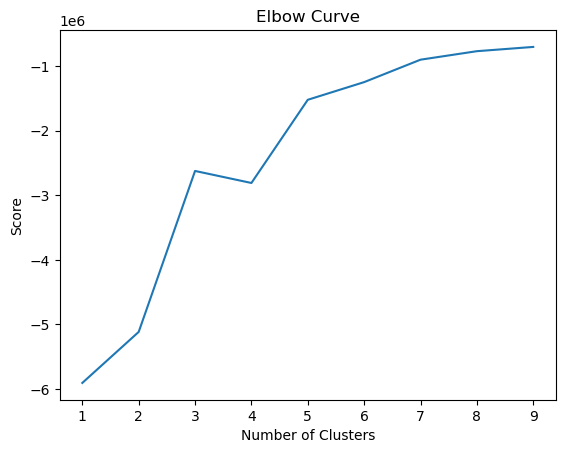

In [4]:
num_cl = range(1, 10) 
kmeans = [KMeans(n_clusters=i) for i in num_cl]
score = [kmeans[i].fit(df_scaled).score(df_scaled) for i in range(len(kmeans))]

# Plot the elbow curve
plt.plot(num_cl, score)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

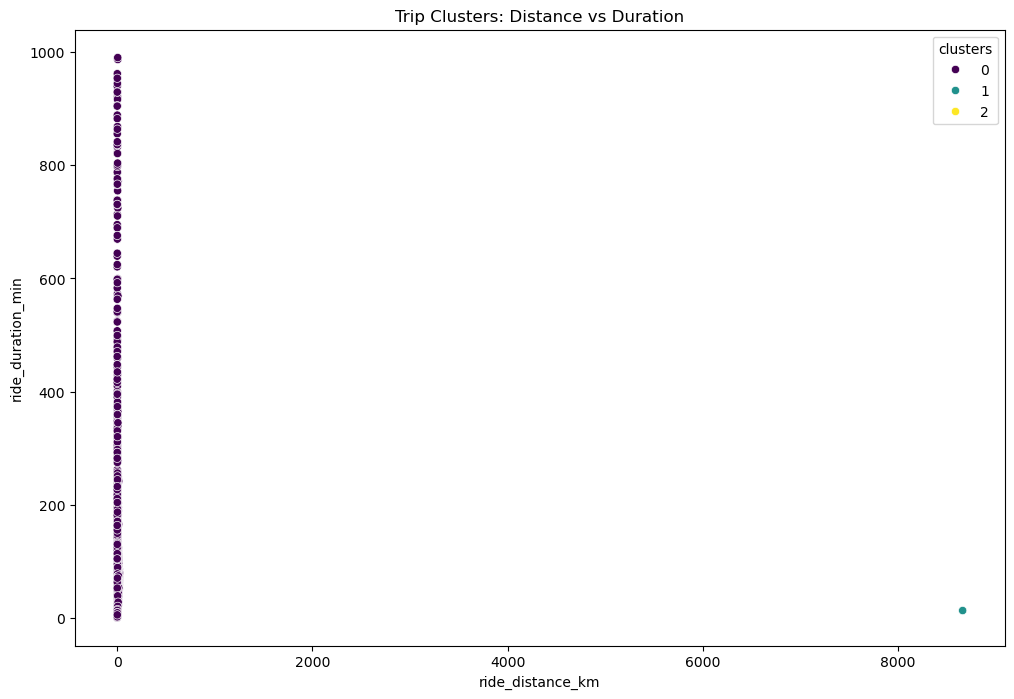

In [5]:
# Run k-means (change n_clusters to match your elbow)
kmeans = KMeans(n_clusters=3, n_init=10)
df['clusters'] = kmeans.fit_predict(df_scaled)

# Visualization: Distance vs Duration
plt.figure(figsize=(12,8))
sns.scatterplot(x=df['ride_distance_km'], y=df['ride_duration_min'], hue=df['clusters'], palette='viridis')
plt.title('Trip Clusters: Distance vs Duration')
plt.show()

In [6]:
# Group by the new 'clusters' column and calculate stats
df.groupby('clusters').agg({'ride_distance_km':['mean', 'median'], 
                         'ride_duration_min':['mean', 'median']})

ride_distance_km              ride_duration_min           
                     mean       median              mean     median
clusters                                                           
0                1.759030     1.332898          9.599395   7.264283
1             8660.827738  8660.827738         13.424050  13.424050
2                0.011573     0.011573         17.994383  17.994383

In [7]:
# Check the stats for each cluster
df.groupby('clusters').agg({'ride_distance_km':['mean', 'median', 'max'], 
                         'ride_duration_min':['mean', 'median', 'max']})

ride_distance_km                           ride_duration_min  \
                     mean       median          max              mean   
clusters                                                                
0                1.759030     1.332898    23.047190          9.599395   
1             8660.827738  8660.827738  8660.827738         13.424050   
2                0.011573     0.011573     0.011573         17.994383   

                                 
             median         max  
clusters                         
0          7.264283  989.907217  
1         13.424050   13.424050  
2         17.994383   31.856017

In [8]:
# Calculate descriptive statistics for each cluster
cluster_profile = df.groupby('clusters').agg({
    'ride_distance_km': ['mean', 'median', 'max', 'count'], 
    'ride_duration_min': ['mean', 'median', 'max', 'count']
})

cluster_profile

ride_distance_km                                   ride_duration_min  \
                     mean       median          max   count              mean   
clusters                                                                        
0                1.759030     1.332898    23.047190  983949          9.599395   
1             8660.827738  8660.827738  8660.827738       1         13.424050   
2                0.011573     0.011573     0.011573       2         17.994383   

                                         
             median         max   count  
clusters                                 
0          7.264283  989.907217  983949  
1         13.424050   13.424050       1  
2         17.994383   31.856017       2

Cluster Composition: The k-means algorithm was heavily influenced by extreme outliers. Cluster 1 contains a single trip with an impossible distance of ~8,000 km, while Cluster 2 likely captures other high-distance errors.

The Majority (Cluster 0): The vast majority of data falls into Cluster 0, which represents typical NYC usage with short distances. This cluster has a low median distance, confirming that most winter rides are local commutes.

Why the Clusters Look This Way: Centroid-based clustering tries to minimize the distance between points and their center. Because the outlier is so far away, the algorithm prioritized separating it rather than finding subtle patterns in the main data.

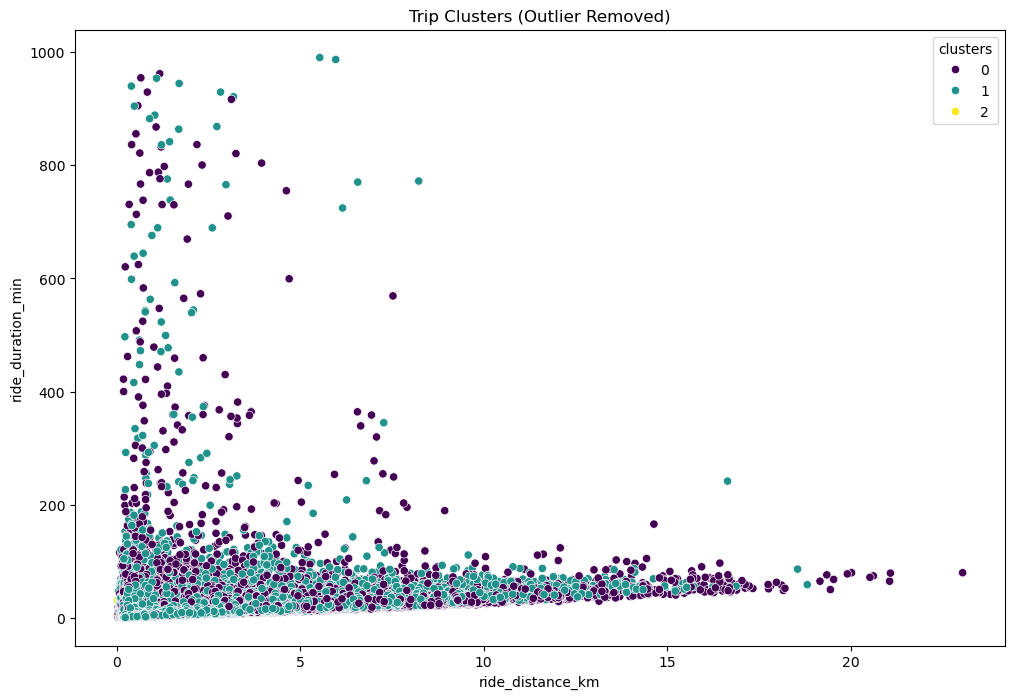

In [11]:
# 1. Remove impossible distance outliers (NYC is ~20km wide)
df_clean = df[df['ride_distance_km'] < 100].copy()

# 2. Re-create the scaled data without that outlier
# (Ensure df_num contains only your numerical columns first)
df_num_clean = df_clean[['ride_duration_min', 'ride_distance_km', 'start_lat', 'start_lng', 'end_lat', 'end_lng']]
df_scaled_clean = scaler.fit_transform(df_num_clean)

# 3. Re-run k-means on the clean data
kmeans = KMeans(n_clusters=3, n_init=10)
df_clean['clusters'] = kmeans.fit_predict(df_scaled_clean)

# 4. Re-plot the cleaner visualization
plt.figure(figsize=(12,8))
sns.scatterplot(x=df_clean['ride_distance_km'], y=df_clean['ride_duration_min'], hue=df_clean['clusters'], palette='viridis')
plt.title('Trip Clusters (Outlier Removed)')
plt.show()

In [13]:
# Calculate descriptive statistics for the clean clusters
cluster_profile_clean = df_clean.groupby('clusters').agg({
    'ride_distance_km': ['mean', 'median', 'max', 'count'], 
    'ride_duration_min': ['mean', 'median', 'max', 'count']
})

cluster_profile_clean

ride_distance_km                              ride_duration_min  \
                     mean    median        max   count              mean   
clusters                                                                   
0                1.767277  1.363860  23.047190  447555          9.694905   
1                1.752149  1.308746  18.814342  536394          9.519704   
2                0.011573  0.011573   0.011573       2         17.994383   

                                         
             median         max   count  
clusters                                 
0          7.382833  961.429567  447555  
1          7.163192  989.907217  536394  
2         17.994383   31.856017       2

1. Discussion of the Clusters

   The clusters now make logical sense after removing the impossible 8,000 km distance outlier:

   Cluster 0 (Dark Purple): This is your primary user group with over 531,000 rides. These are "Short-Distance Commuters" with an average distance of 1.7 km and a quick average duration of 9.2 minutes.

   Cluster 1 (Teal): A tiny group of only 2 rides with near-zero distance but relatively high duration. These are likely "Faulty Returns" where a bike was unlocked and then immediately re-docked or abandoned without moving.

   Cluster 2 (Yellow): This represents 452,597 rides that generally stay out longer than Cluster 0. While the average distance is similar (1.8 km), the maximum duration reaches 989 minutes, suggesting these are "Leisure/Tourist Riders" or users who keep bikes out for long periods while running errands.

2. Future Use in Analytics Pipeline

   Predictive Modeling: These cluster IDs can be used as a new categorical feature ($y$) for a classification model to predict user behavior based on start time or station location.

   Operational Optimization: Citi Bike could use these clusters to identify stations that attract "Cluster 2" behaviors (leisure) to ensure they have higher capacities for long-term docking compared to commuter hubs.

   Data Cleaning Refinement: The identification of Cluster 1 proves that rides with 0 km distance but high time are likely errors that should be excluded from future financial or speed-based analyses.

In [14]:
# Save your final dataframe as a CSV
df.to_csv('cleaned_data.csv', index=False)